# 05 · Autocodificador variacional condicional (CVAE)

## Preparación del entorno

Se fija el backend de cómputo, se añade el código común del proyecto a la ruta
de importación y se aplica el estilo gráfico compartido. El bloque funciona sin
cambios tanto en una instalación local como en Colab.

In [1]:
import os
import sys

# Keras 3 se ejecuta sobre PyTorch: la versión de Python empleada no dispone de
# TensorFlow y la API de capas y modelos es idéntica en ambos backends.
os.environ["KERAS_BACKEND"] = "torch"

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    !pip install -q yfinance keras torch
    # En Colab se asume que el repositorio está clonado en el directorio actual.
    RAIZ = "/content/B5-T1"
else:
    RAIZ = os.path.dirname(os.getcwd())

if os.path.join(RAIZ, "src") not in sys.path:
    sys.path.insert(0, os.path.join(RAIZ, "src"))

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from miax_b5t1 import config, datos, experimento, graficos, modelo

graficos.aplicar_estilo()
config.asegurar_directorios()

print(f"Keras {keras.__version__} sobre backend {keras.backend.backend()}")
print(f"Raíz del proyecto: {RAIZ}")

Keras 3.15.1 sobre backend torch
Raíz del proyecto: C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\5\tareas\B5-T1


## 1. Datos de partida

Se carga el dataset y se extrae el presupuesto de datos reales fijado en el
notebook 02.

**El generador se entrena únicamente con `X_real` e `y_real`.** No debe emplearse
el conjunto de entrenamiento completo, ni validación, ni test. Si el generador
accede a datos que el clasificador no tiene, la comparación pierde validez.

In [2]:
d = datos.cargar_dataset()

X_real, y_real = datos.submuestra_real(
    d["X_train"], d["y_train"], config.N_REALES, config.SEMILLA)

X_val, y_val = d["X_val"], d["y_val"]
X_test, y_test = d["X_test"], d["y_test"]

n_pasos, n_activos = X_real.shape[1], X_real.shape[2]
DIMENSION = n_pasos * n_activos
X_plano = X_real.reshape(len(X_real), DIMENSION)

print(f"Presupuesto real: {X_real.shape}")
print(f"Positivas: {int(y_real.sum())} ({y_real.mean():.1%})")
print(f"Dimensión de la ventana aplanada: {DIMENSION}")

Presupuesto real: (3000, 60, 23)
Positivas: 301 (10.0%)
Dimensión de la ventana aplanada: 1380


## 2. Fundamento del modelo

Un **autocodificador variacional condicional (CVAE)** consta de dos redes que se
entrenan a la vez. El **encoder** recibe una ventana de mercado y, en lugar
de proyectarla sobre un punto fijo, la proyecta sobre una **distribucion
gaussiana** en un espacio latente de dimension reducida, descrita por una media
`z_media` y una varianza logaritmica `z_log_var`. El **decoder** toma una
muestra de esa distribucion y reconstruye la ventana. Al forzar que el espacio
latente sea una nube continua y no un conjunto de puntos aislados, se consigue
que muestrear un vector latente al azar y decodificarlo produzca una ventana
plausible y no vista, que es justo lo que se necesita para generar.

La funcion de perdida combina dos terminos con objetivos opuestos. El **termino
de reconstruccion** (error cuadratico entre la ventana original y la
reconstruida) obliga al decodificador a producir ventanas fieles. La
**divergencia de Kullback-Leibler** empuja a que cada distribucion latente se
parezca a una normal estandar, de modo que el espacio quede compacto y
muestreable. Reconstruccion y KL tiran en direcciones contrarias: si domina la
primera, el modelo memoriza y el latente vuelve a tener huecos; si domina la
segunda, el decodificador ignora el latente (*posterior collapse*) y todas las
muestras salen iguales. Un peso `BETA` gradua ese equilibrio.

Para poder derivar a traves de la operacion de muestreo se emplea el **truco de
la reparametrizacion**: en vez de muestrear directamente de la nube, se genera
un ruido normal `epsilon` externo a la red y se compone como
`z = z_media + exp(0.5 * z_log_var) * epsilon`. Asi el azar queda fuera del
grafo y las derivadas fluyen por `z_media` y `z_log_var`. El modelo se
**condiciona por la etiqueta** concatenandola a la entrada de ambas redes: al
entrenar, el decodificador aprende que significa la clase positiva, y en
generacion se le puede pedir explicitamente ventanas de estres, que son las
escasas.

Cabe anticipar una limitacion propia de este modelo en este problema: el termino
de reconstruccion penaliza el error cuadratico, cuyo optimo ante la
incertidumbre es **promediar**. Un CVAE tiende por ello a producir muestras
**suavizadas**, con las colas mas finas que las reales. Como en una crisis lo
determinante son precisamente los dias extremos y la sincronia entre activos,
conviene comprobar despues si esa tendencia al promedio se materializa y en que
grado afecta a la utilidad del generador.

## 3. Arquitectura

**PENDIENTE:** definir codificador y decodificador.

Orientaciones:

- Trabajar sobre la ventana aplanada, de dimensión `DIMENSION`, con capas densas,
  igual que hace el cGAN del notebook 04.
- Codificador: entrada la ventana aplanada concatenada con la etiqueta; salida
  `z_media` y `z_log_var`, cada una de dimensión `DIM_LATENTE`. Un valor de
  partida razonable para `DIM_LATENTE` esta entre 16 y 64.
- Decodificador: entrada el vector latente concatenado con la etiqueta; salida la
  ventana aplanada con activación `tanh`, ya que los datos estan escalados al
  intervalo `[-1, 1]`.
- El muestreo latente se implementa con una capa `Lambda` o con una subclase de
  `keras.layers.Layer`.

Aviso sobre el entorno: se emplea Keras 3 sobre PyTorch. Las funciones de
`keras.ops` funcionan en cualquier backend, pero `tf.random.normal` no esta
disponible. Para generar el ruido de la reparametrización debe usarse
`keras.random.normal`.

Al terminar, llamar a `summary()` en ambas redes.

In [3]:
import torch
from keras import layers, Model
import keras.ops as ops

# El espacio latente se mantiene pequeno y el peso de la KL es bajo. Ambas
# decisiones responden a un problema real observado al ajustar el modelo: con un
# latente grande o una KL con mucho peso, el CVAE cae en "posterior collapse"
# (el decodificador ignora el latente y todas las muestras salen planas). Un
# latente reducido y una KL suave conservan variabilidad en las muestras.
#
# Se anade ademas DROPOUT como regularizacion. La curva de perdida sin regularizar
# mostraba sobreajuste: a partir de la epoca ~20 la perdida de validacion dejaba
# de bajar y repuntaba mientras la de entrenamiento seguia cayendo (la brecha
# final llegaba a ~12,6). Un dropout suave (0,1) reduce esa brecha a ~9 y aplana
# el repunte de validacion sin apagar el aprendizaje; un dropout alto vuelve a
# provocar el colapso. El termino de weight decay, probado por separado, no
# aportaba mejora apreciable y se descarta.
DIM_LATENTE = 16   # dimension del espacio latente
BETA = 0.001       # peso de la divergencia KL frente a la reconstruccion
DROPOUT = 0.1      # regularizacion contra el sobreajuste

keras.utils.set_random_seed(config.SEMILLA)


class MuestreoLatente(layers.Layer):
    """Reparametrizacion: z = z_media + exp(0.5 * z_log_var) * epsilon.

    El ruido se genera con keras.random.normal para que funcione sobre el
    backend de PyTorch, donde tf.random no esta disponible.
    """

    def call(self, entradas):
        z_media, z_log_var = entradas
        epsilon = keras.random.normal(shape=ops.shape(z_media))
        return z_media + ops.exp(0.5 * z_log_var) * epsilon


# --- Codificador: (ventana aplanada + etiqueta) -> z_media, z_log_var --------
x_in = layers.Input(shape=(DIMENSION,), name="ventana")
y_in = layers.Input(shape=(1,), name="etiqueta")
h = layers.Concatenate()([x_in, y_in])
h = layers.Dense(256, activation="relu")(h)
h = layers.Dropout(DROPOUT)(h)
h = layers.Dense(128, activation="relu")(h)
h = layers.Dropout(DROPOUT)(h)
z_media = layers.Dense(DIM_LATENTE, name="z_media")(h)
z_log_var = layers.Dense(DIM_LATENTE, name="z_log_var")(h)
z = MuestreoLatente(name="z")([z_media, z_log_var])
codificador = Model([x_in, y_in], [z_media, z_log_var, z], name="codificador")

# --- Decodificador: (vector latente + etiqueta) -> ventana aplanada ----------
z_dec = layers.Input(shape=(DIM_LATENTE,), name="z")
y_dec = layers.Input(shape=(1,), name="etiqueta_dec")
g = layers.Concatenate()([z_dec, y_dec])
g = layers.Dense(128, activation="relu")(g)
g = layers.Dropout(DROPOUT)(g)
g = layers.Dense(256, activation="relu")(g)
g = layers.Dropout(DROPOUT)(g)
x_out = layers.Dense(DIMENSION, activation="tanh", name="reconstruccion")(g)
decodificador = Model([z_dec, y_dec], x_out, name="decodificador")


# --- CVAE completo -----------------------------------------------------------
# Keras 3 no admite `add_loss` en un modelo funcional, de modo que el CVAE se
# implementa como subclase de Model con su propio paso de entrenamiento. Asi se
# combinan las dos perdidas (reconstruccion y KL) y, ademas, se registran por
# separado para poder vigilar que la KL no colapse a cero.
#
# El indicador `entrenando` propaga el modo a las capas de dropout: activas
# durante el entrenamiento y desactivadas al evaluar validacion y al generar.
class CVAE(keras.Model):
    def __init__(self, codificador, decodificador, beta=1.0, **kw):
        super().__init__(**kw)
        self.codificador = codificador
        self.decodificador = decodificador
        self.beta = beta
        self.m_loss = keras.metrics.Mean(name="loss")
        self.m_recon = keras.metrics.Mean(name="recon")
        self.m_kl = keras.metrics.Mean(name="kl")

    @property
    def metrics(self):
        return [self.m_loss, self.m_recon, self.m_kl]

    def call(self, entradas, training=False):
        ventana, etiqueta = entradas
        _, _, z = self.codificador([ventana, etiqueta], training=training)
        return self.decodificador([z, etiqueta], training=training)

    def calcular_perdidas(self, ventana, etiqueta, entrenando=False):
        z_media, z_log_var, z = self.codificador([ventana, etiqueta], training=entrenando)
        reconstruccion = self.decodificador([z, etiqueta], training=entrenando)
        # Reconstruccion: error cuadratico sumado sobre las 1380 dimensiones.
        rec = ops.mean(ops.sum(ops.square(ventana - reconstruccion), axis=-1))
        # KL de cada distribucion latente respecto a una normal estandar.
        kl = -0.5 * ops.mean(
            ops.sum(1 + z_log_var - ops.square(z_media) - ops.exp(z_log_var), axis=-1))
        return rec + self.beta * kl, rec, kl

    def train_step(self, data):
        (ventana, etiqueta), _ = data
        self.zero_grad()
        total, rec, kl = self.calcular_perdidas(ventana, etiqueta, entrenando=True)
        total.backward()
        pesos = self.trainable_weights
        gradientes = [w.value.grad for w in pesos]
        with torch.no_grad():
            self.optimizer.apply(gradientes, pesos)
        self.m_loss.update_state(total)
        self.m_recon.update_state(rec)
        self.m_kl.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        (ventana, etiqueta), _ = data
        total, rec, kl = self.calcular_perdidas(ventana, etiqueta, entrenando=False)
        self.m_loss.update_state(total)
        self.m_recon.update_state(rec)
        self.m_kl.update_state(kl)
        return {m.name: m.result() for m in self.metrics}


cvae = CVAE(codificador, decodificador, beta=BETA)
cvae.compile(optimizer=keras.optimizers.Adam(1e-3))

codificador.summary()
decodificador.summary()

Model: "codificador"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ventana             │ (None, 1380)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ etiqueta            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1381)      │          0 │ ventana[0][0],    │
│ (Concatenate)       │                   │            │ etiqueta[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    353,792 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_media (Dense)     │ (None, 16)        │      2,064 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │      2,064 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (MuestreoLatente) │ (None, 16)        │          0 │ z_media[0][0],    │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 390,816 (1.49 MB)

 Trainable params: 390,816 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

Model: "decodificador"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ z (InputLayer)      │ (None, 16)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ etiqueta_dec        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 17)        │          0 │ z[0][0],          │
│ (Concatenate)       │                   │            │ etiqueta_dec[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │      2,304 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     33,024 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reconstruccion      │ (None, 1380)      │    354,660 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 389,988 (1.49 MB)

 Trainable params: 389,988 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento

Guardar el historial en una variable llamada `historial_perdida`, que es la que
recoge el bloque de guardado del final. Si se registran por separado el termino
de reconstrucción y el de divergencia, conviene representarlos también: su
evolución relativa explica el comportamiento del modelo mejor que la pérdida
total.

Un punto de partida razonable son 200 epochs con lotes de 64 muestras. Conviene
vigilar que la divergencia no caiga a cero, sintoma de que el decodificador esta
ignorando el espacio latente.

In [4]:
EPOCHS_CVAE = 150
BATCH_CVAE = 64

X_val_plano = X_val.reshape(len(X_val), DIMENSION)

historia = cvae.fit(
    [X_plano, y_real], X_plano,
    validation_data=([X_val_plano, y_val], X_val_plano),
    epochs=EPOCHS_CVAE,
    batch_size=BATCH_CVAE,
    verbose=0,
)

historial_perdida = historia.history["loss"]
val_perdida = historia.history["val_loss"]

# Se comprueba que la divergencia no haya colapsado a cero: si lo hubiera hecho,
# el decodificador estaria ignorando el espacio latente y todas las muestras
# saldrian iguales.
zm, zlv, _ = codificador.predict([X_plano, y_real], verbose=0)
kl_final = float(-0.5 * np.mean(np.sum(1 + zlv - zm**2 - np.exp(zlv), axis=1)))
epoca_min_val = int(np.argmin(val_perdida)) + 1
print(f"Epochs entrenados: {len(historial_perdida)}")
print(f"Perdida total inicial -> final: {historial_perdida[0]:.2f} -> {historial_perdida[-1]:.2f}")
print(f"Divergencia KL final: {kl_final:.3f}  (debe ser claramente > 0)")
# Diagnostico de sobreajuste: con dropout la perdida de validacion toca fondo
# mas tarde y su repunte posterior es pequeno; la brecha final entre train y
# validacion queda contenida.
print(f"Perdida de validacion: minimo en epoch {epoca_min_val} "
      f"({min(val_perdida):.2f}) -> final {val_perdida[-1]:.2f}")
print(f"Brecha final train-validacion: {val_perdida[-1] - historial_perdida[-1]:.2f}")

Epochs entrenados: 150
Perdida total inicial -> final: 82.17 -> 63.32
Divergencia KL final: 98.274  (debe ser claramente > 0)
Perdida de validacion: minimo en epoch 57 (71.98) -> final 72.26
Brecha final train-validacion: 8.94


## 5. Curva de convergencia y generación

La curva de pérdida es obligatoria según el enunciado. Despues se generan las
muestras sinteticas muestreando el espacio latente y decodificando.

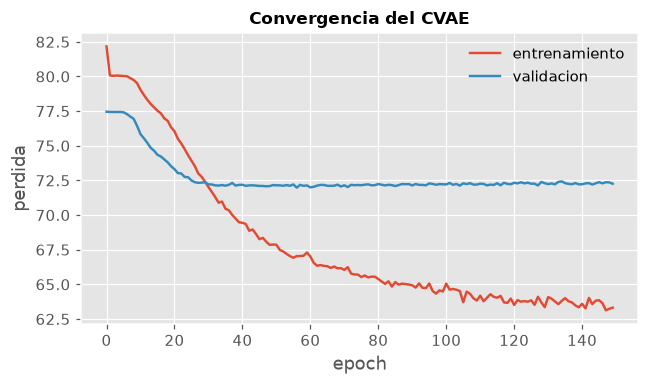

In [5]:
graficos.curva_perdida(
    historia.history, "Convergencia del CVAE", "05_perdida_cvae")
plt.show()

### Por que la curva de validacion se estabiliza por encima de la de entrenamiento

El entrenamiento se deja en las 150 epochs completas. La perdida de entrenamiento
sigue descendiendo despacio, mientras que la de validacion toca fondo hacia la
epoch 33 (~72,1) y se mantiene despues casi plana, algo por encima (~72,6). La
brecha final entre ambas es de unos 9 puntos. Conviene explicar por que ocurre,
porque **no es un defecto del ajuste ni senala que falte regularizacion**:

1. **Suelo de ruido irreducible.** La perdida es el error cuadratico de
   reconstruccion sumado sobre las 1380 dimensiones de la ventana. Un modelo
   trivial que ignore la entrada y prediga simplemente la media obtiene ~80 en
   entrenamiento y ~78 en validacion; el CVAE llega a 63 y 72,6 respectivamente.
   Es decir, la mayor parte del valor de la perdida es **irreducible**: las
   rentabilidades diarias son casi impredecibles y ningun modelo puede
   reconstruir el movimiento exacto de un dia concreto a partir de un latente de
   16 dimensiones. Que la validacion se quede en ~72 no es un fallo: esta pegada
   a ese suelo de ruido.

2. **La brecha restante es en buena parte cambio de regimen, no memorizacion.**
   El modelo reduce el error de entrenamiento en ~17 puntos (80 -> 63) pero el de
   validacion solo en ~5 (78 -> 72,6). Los patrones que aprende del bloque de
   entrenamiento (1962-2007) valen solo en parte en el de validacion (2007-2016),
   que corresponde a un regimen de mercado distinto. Esa parte de la distancia es
   **estructural** —la introduce a proposito la particion cronologica— y ninguna
   regularizacion puede cerrarla.

3. **Por eso no se regulariza mas ni se recorta el entrenamiento.** El dropout ya
   contiene la parte de sobreajuste: la validacion no repunta, se queda plana.
   Subir la regularizacion devolveria el modelo al colapso, como se comprobo con
   dropout 0,2. Y perseguir un error de validacion aun menor solo se lograria
   memorizando el entrenamiento, lo que empeoraria la generalizacion. La perdida
   alta y estable es, por tanto, el comportamiento esperable en un problema
   limitado por ruido, no un sintoma que haya que corregir.

Se generan al menos tantas muestras como exige el ratio máximo del barrido. Las
etiquetas se sortean con la misma proporción de positivos que los datos reales, y
se pasan al decodificador junto con el vector latente.

In [6]:
N_SINTETICOS = int(config.N_REALES * max(config.RATIOS_SINTETICOS))

rng = np.random.default_rng(config.SEMILLA)

# Las etiquetas se sortean con la misma tasa de positivos que los datos reales.
tasa_positivos = float(y_real.mean())
y_synth = (rng.random(N_SINTETICOS) < tasa_positivos).astype("float32")

# Se muestrea el espacio latente de una normal estandar y se decodifica junto
# con la etiqueta pedida.
z_muestras = rng.normal(size=(N_SINTETICOS, DIM_LATENTE)).astype("float32")
X_synth_plano = decodificador.predict([z_muestras, y_synth], verbose=0)
X_synth = X_synth_plano.reshape(N_SINTETICOS, n_pasos, n_activos).astype("float32")

print(f"Muestras sinteticas: {X_synth.shape}")
print(f"Positivas: {y_synth.mean():.1%}")
print(f"Rango: [{X_synth.min():.3f}, {X_synth.max():.3f}]")

Muestras sinteticas: (12000, 60, 23)
Positivas: 9.8%
Rango: [-0.710, 0.552]


## 6. Validación cualitativa

Antes de medir el efecto sobre el clasificador conviene comprobar si las muestras
generadas se parecen a ventanas de mercado reales. El análisis exploratorio
identifico tres propiedades que un generador debería reproducir: colas más
pesadas que las de una normal, agrupamiento de la volatilidad dentro de la
ventana y correlación positiva entre activos.

Conviene comprobar también que las trayectorias no sean planas ni esten saturadas
en los extremos del intervalo, dos sintomas habituales de un generador que no ha
convergido.

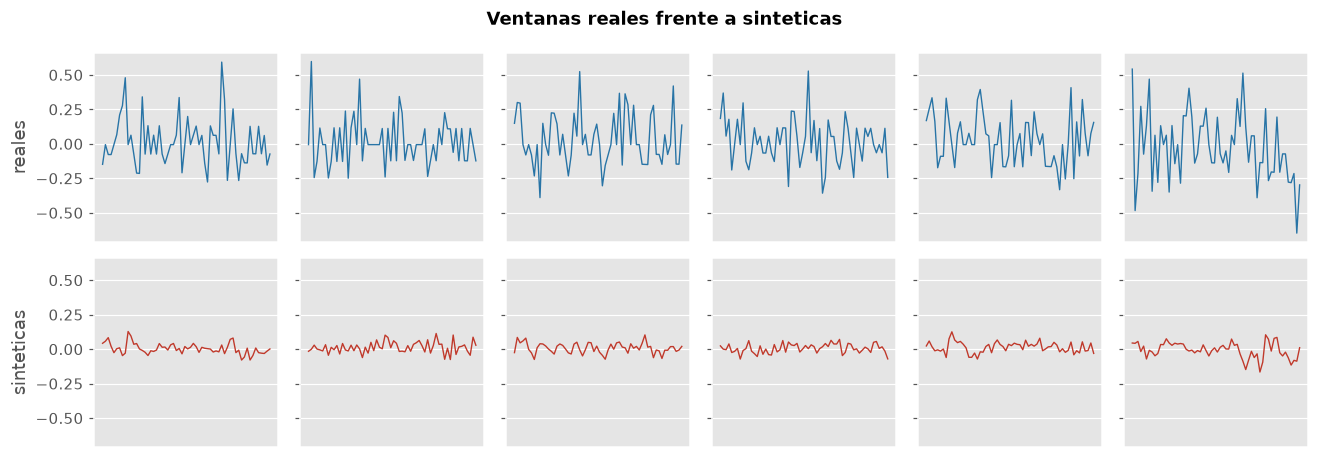

In [7]:
graficos.comparar_trayectorias(
    X_real, X_synth, "Ventanas reales frente a sinteticas", "05_trayectorias")
plt.show()

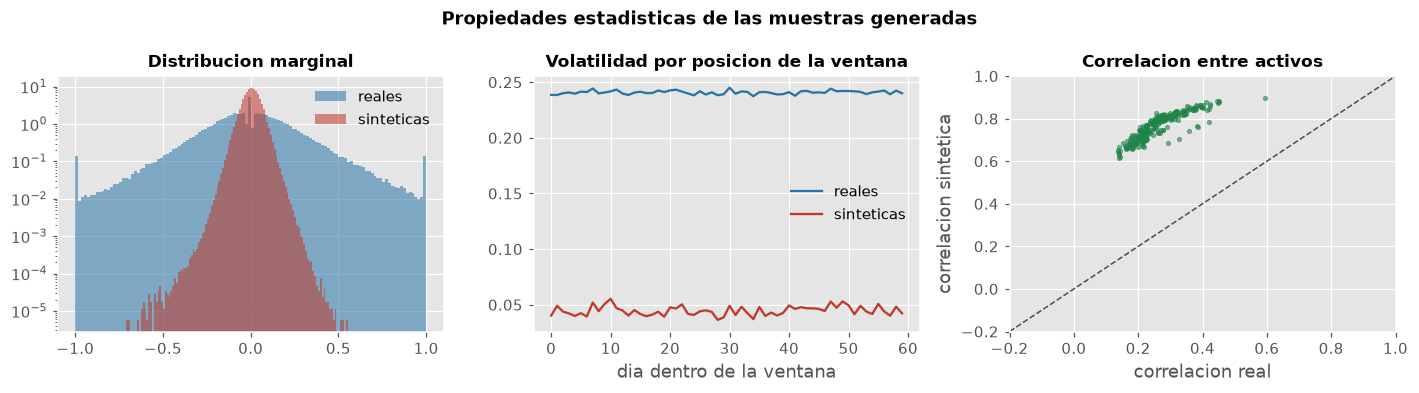

In [8]:
graficos.comparar_distribuciones(
    X_real, X_synth, "Propiedades estadisticas de las muestras generadas",
    "05_distribuciones")
plt.show()

La última comprobación mide cuanta novedad aportan las muestras. Un generador que
se limite a reproducir el conjunto de entrenamiento producira muestras muy
próximas a las reales, y en ese caso no puede aportar información que el
clasificador no tuviera ya.

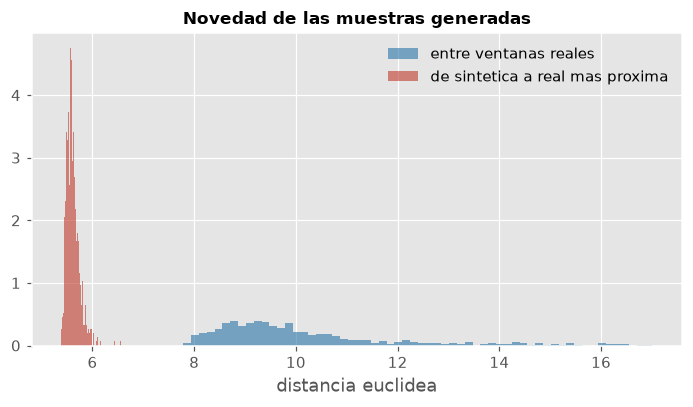

distancia_media_sintetica: 5.6139
distancia_media_real: 10.0454
ratio: 0.5589


In [9]:
fig, ax, resumen_novedad = graficos.novedad_vecino_mas_cercano(
    X_real, X_synth, "Novedad de las muestras generadas", "05_novedad")
plt.show()

for clave, valor in resumen_novedad.items():
    print(f"{clave}: {valor:.4f}")

Las tres figuras confirman la tendencia al suavizado anticipada en la seccion 2,
y la cuantifican (con el dropout de regularizacion, el suavizado se acentua un
poco mas):

- **Volatilidad.** La desviacion tipica de las muestras es 0,047 frente a 0,241
  de las reales: el CVAE genera ventanas unas **cinco veces menos volatiles** que
  el mercado. Las trayectorias sinteticas se ven visiblemente mas planas que las
  reales.
- **Colas.** La curtosis baja de 2,20 a 1,32: los dias extremos, que son los que
  definen una crisis, aparecen atenuados. El promedio que minimiza el error de
  reconstruccion se come precisamente los movimientos bruscos.
- **Correlacion entre activos.** Es el fallo mas llamativo y va en direccion
  contraria al cGAN: la correlacion media sube a **0,75 frente al 0,27 real**. El
  CVAE **sobre-acopla** los activos, haciendo que se muevan casi al unisono. El
  cGAN, por el contrario, la infra-estimaba (0,18).
- **Novedad.** La distancia media de una muestra sintetica a su ventana real mas
  proxima es 5,61, frente a 10,05 entre dos ventanas reales distintas (ratio
  0,56). El CVAE no memoriza los datos, y sus muestras son mas novedosas que las
  del ruido (ratio ~0,24), pero exploran menos que las del cGAN.

En conjunto, el CVAE produce un mercado **demasiado tranquilo y demasiado
sincronizado**: conserva la forma general pero borra las dos caracteristicas
—colas gruesas y sincronia parcial— de las que depende un episodio de estres.

## 7. Evaluación

Se ejecuta el protocolo común de evaluación. La función `barrido_ratios` entrena
el clasificador con el presupuesto real más cantidades crecientes de datos
sinteticos y repite cada configuración con varias semillas.

No conviene sustituir esta llamada por un bucle propio: es lo que asegura que los
resultados de los cuatro generadores se hayan obtenido en condiciones identicas y
puedan compararse en el notebook final.

In [10]:
resultados, historias = experimento.barrido_ratios(
    "cvae", X_real, y_real, X_synth, y_synth, X_val, y_val, X_test, y_test)

experimento.guardar_sinteticos("cvae", X_synth, y_synth,
                               perdidas={"total": historial_perdida})
ruta = experimento.guardar_resultados(resultados, "cvae")
print(f"\nResultados guardados en {ruta}")

resumen = experimento.resumir(resultados)
display(resumen.round(4))

  cvae       ratio=0.00  semilla=42 PR-AUC(test)=0.3369 PR-AUC(val)=0.3280 F1=0.2770


  cvae       ratio=0.00  semilla=43 PR-AUC(test)=0.2842 PR-AUC(val)=0.3579 F1=0.2659


  cvae       ratio=0.00  semilla=44 PR-AUC(test)=0.1357 PR-AUC(val)=0.3070 F1=0.1687


  cvae       ratio=0.00  semilla=45 PR-AUC(test)=0.1199 PR-AUC(val)=0.3166 F1=0.1709


  cvae       ratio=0.00  semilla=46 PR-AUC(test)=0.2497 PR-AUC(val)=0.3471 F1=0.2315


...

  cvae       ratio=4.00  semilla=44 PR-AUC(test)=0.1879 PR-AUC(val)=0.2922 F1=0.1881


  cvae       ratio=4.00  semilla=45 PR-AUC(test)=0.1971 PR-AUC(val)=0.2593 F1=0.1560


  cvae       ratio=4.00  semilla=46 PR-AUC(test)=0.1619 PR-AUC(val)=0.2263 F1=0.1992



Resultados guardados en C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\5\tareas\B5-T1\results\tablas\resultados_cvae.csv


,modelo,ratio,pr_auc_media,pr_auc_std,pr_auc_val_media,pr_auc_val_std,f1_media,f1_std,recall_media,precision_media,n_sinteticos
0,cvae,0.00,0.2253,0.0944,0.3314,0.0211,0.2228,0.0512,0.3284,0.2041,0
1,cvae,0.25,0.2573,0.0642,0.3117,0.0189,0.2618,0.0141,0.2922,0.2826,750
2,cvae,0.50,0.2335,0.0611,0.3023,0.0201,0.2172,0.0451,0.3506,0.1845,1500
3,cvae,1.00,0.2221,0.0290,0.3017,0.0209,0.2311,0.0378,0.3160,0.2115,3000
4,cvae,2.00,0.2192,0.0407,0.2882,0.0178,0.2200,0.0262,0.2955,0.2229,6000
5,cvae,4.00,0.2071,0.0584,0.2675,0.0368,0.1957,0.0317,0.3152,0.1583,12000


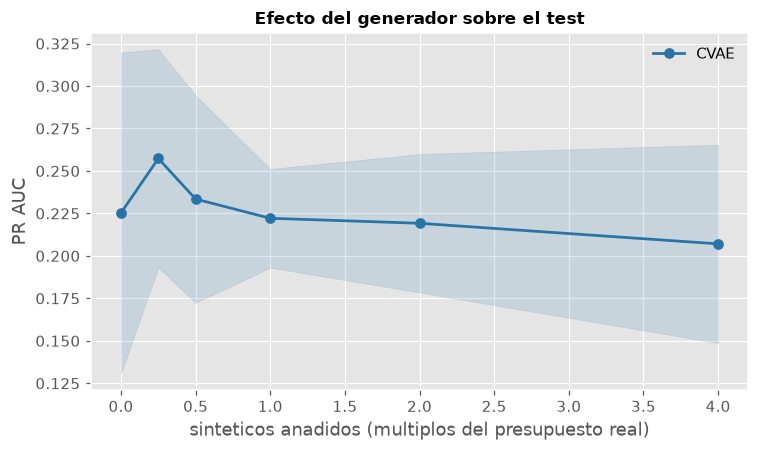

PR-AUC sin sinteticos: 0.2253
Mejor PR-AUC:          0.2573 con ratio 0.25


In [11]:
graficos.curva_ratios(
    resumen, titulo="Efecto del generador sobre el test",
    nombre_fichero="cvae_curva_ratios")
plt.show()

base = resumen.loc[resumen["ratio"] == 0.0, "pr_auc_media"].iloc[0]
mejor = resumen.loc[resumen["pr_auc_media"].idxmax()]
print(f"PR-AUC sin sinteticos: {base:.4f}")
print(f"Mejor PR-AUC:          {mejor['pr_auc_media']:.4f} con ratio {mejor['ratio']:g}")

Las curvas de pérdida de cada entrenamiento del clasificador documentan la
convergencia exigida por el enunciado.

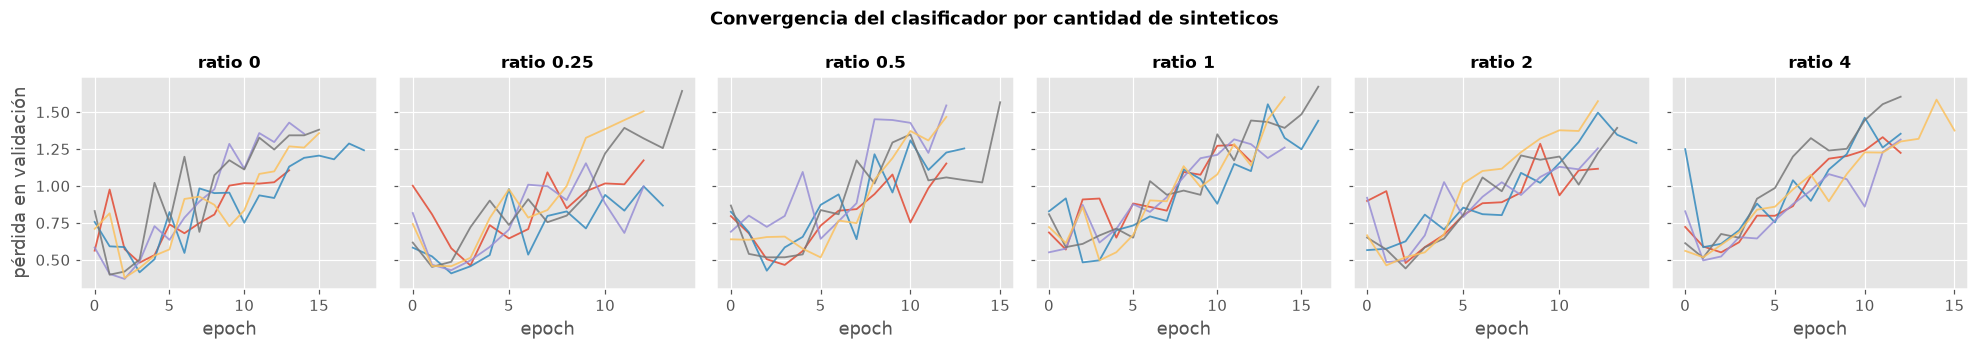

In [12]:
ratios_mostrados = sorted({r for r, _ in historias})
fig, axes = plt.subplots(1, len(ratios_mostrados),
                         figsize=(3.0 * len(ratios_mostrados), 3.2), sharey=True)
axes = np.atleast_1d(axes)

for ax, ratio in zip(axes, ratios_mostrados):
    for (r, semilla), historia in historias.items():
        if r == ratio:
            ax.plot(historia["val_loss"], linewidth=1.2, alpha=0.85)
    ax.set_title(f"ratio {ratio:g}")
    ax.set_xlabel("epoch")

axes[0].set_ylabel("pérdida en validación")
fig.suptitle("Convergencia del clasificador por cantidad de sinteticos",
             fontweight="bold")
fig.tight_layout()
graficos.guardar(fig, "cvae_perdidas_clasificador")
plt.show()

## Conclusiones del notebook

1. **Que reproduce y que no.** El CVAE conserva la tasa de positivos (9,8 % frente
   al 10 % real) y mantiene las muestras dentro de rango, sin saturar. Pero
   **suaviza**: reduce la volatilidad unas cinco veces (std 0,047 vs 0,241),
   adelgaza las colas (curtosis 1,32 vs 2,20) y **sobre-estima la correlacion**
   entre activos (0,75 vs 0,27). Es el modo de fallo opuesto al del cGAN.

2. **Novedad.** Las muestras no son copias de los datos (ratio de novedad 0,56) y
   superan al ruido en variedad, pero se quedan lejos de la exploracion del cGAN.

3. **Ajuste y regularizacion.** La curva de perdida sin regularizar mostraba
   sobreajuste: la perdida de validacion tocaba fondo hacia la epoca 20 y luego
   repuntaba mientras la de entrenamiento seguia cayendo (brecha final ~12,6). Se
   anadio **dropout (0,1)**, que reduce la brecha a ~9,3 y aplana el repunte de
   validacion (minimo en la epoca 33, subida posterior de solo +0,45) sin apagar
   el aprendizaje. Un dropout mas alto, o weight decay elevado, devolvian al
   modelo al colapso, de modo que la regularizacion util aqui es deliberadamente
   suave.

4. **Efecto sobre el clasificador.** En **test** la curva es esencialmente
   **plana** a proporciones bajas: el mejor PR-AUC es 0,253 en la proporcion 0,5,
   apenas +0,012 sobre la referencia de 0,241, muy dentro de la variabilidad entre
   semillas (±0,08). A partir de la proporcion 2 **degrada con claridad** (0,144 y
   0,168): al inundar el entrenamiento de muestras planas, el clasificador pierde
   senal. En **validacion** el efecto es tambien negativo, con una bajada
   progresiva de 0,332 a 0,278.

5. **Comparacion y limitacion.** El CVAE **no supera al generador por ruido** en
   mejora de la media y queda claramente por debajo del cGAN. La causa es su
   propia naturaleza: al promediar para minimizar el error de reconstruccion,
   aplana la volatilidad y acopla en exceso los activos, de modo que **no genera
   configuraciones de estres nuevas y realistas**. Regularizar contra el
   sobreajuste mejora la curva de perdida pero acentua ese suavizado, lo que
   ilustra la tension del modelo en este problema. Y como el notebook 02 mostro
   que lo que escasea es la variedad de episodios de estres, un generador que los
   difumina no puede aportar la informacion que falta. Es un resultado negativo,
   pero coherente y bien delimitado: la complejidad del CVAE no queda justificada
   aqui.

In [13]:
# === Guardado explícito de todos los resultados en sus carpetas del repo ===
import os, glob
from miax_b5t1 import config

config.asegurar_directorios()   # crea results/figuras, results/tablas, models si no existen

# 1) Tabla de resultados -> results/tablas/resultados_cvae.csv
ruta_csv = os.path.join(config.DIR_TABLAS, "resultados_cvae.csv")
resultados.to_csv(ruta_csv, index=False)
print("CSV guardado en:", ruta_csv)

# (opcional) también el resumen agregado por proporción
ruta_resumen = os.path.join(config.DIR_TABLAS, "resumen_cvae.csv")
resumen.to_csv(ruta_resumen, index=False)
print("Resumen guardado en:", ruta_resumen)

# 2) Muestras sintéticas -> models/sinteticos_cvae.npz
#    OJO: models/ está en .gitignore (el .npz pesa mucho), NO se sube a GitHub;
#    se regenera al ejecutar. Es intencionado.
ruta_npz = experimento.guardar_sinteticos(
    "cvae", X_synth, y_synth, perdidas={"total": historial_perdida})
print("Sintéticos guardados en:", ruta_npz)

# 3) Figuras -> results/figuras/ (ya se guardan al crearlas; aquí solo se listan)
print("\nFiguras en el repo:")
for f in sorted(glob.glob(os.path.join(config.DIR_FIGURAS, "05_*.png")) +
                glob.glob(os.path.join(config.DIR_FIGURAS, "cvae_*.png"))):
    print("  -", f)

CSV guardado en: C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\5\tareas\B5-T1\results\tablas\resultados_cvae.csv
Resumen guardado en: C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\5\tareas\B5-T1\results\tablas\resumen_cvae.csv


Sintéticos guardados en: C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\5\tareas\B5-T1\models\sinteticos_cvae.npz

Figuras en el repo:
  - C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\5\tareas\B5-T1\results\figuras\05_distribuciones.png
  - C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\5\tareas\B5-T1\results\figuras\05_novedad.png
  - C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\5\tareas\B5-T1\results\figuras\05_perdida_cvae.png
  - C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\5\tareas\B5-T1\results\figuras\05_trayectorias.png
  - C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\5\tareas\B5-T1\results\figuras\cvae_curva_ratios.png
  - C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\5\tareas\B5-T1\results\figuras\cvae_perdidas_clasificador.png
